In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr,spearmanr
import os
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import seaborn as sns
import networkx as nx
from ndex2.nice_cx_network import NiceCXNetwork
import ndex2
import json
import matplotlib as mpl

In [2]:
rcd_nwcx=ndex2.create_nice_cx_from_file("genesets/RCD_genesets/RCD_map/Regulated Cell Death.cx")

In [3]:
rcd_nwcx.print_summary()

Name: Regulated Cell Death
Nodes: 5079
Edges: 5958
Node Attributes: 33305
Edge Attributes: 17874



In [4]:
rcd_nw=NiceCXNetwork.to_networkx(rcd_nwcx)

In [5]:
import itertools
def remove_node(g, nodes):
    totalnewedges=[]
    for node in nodes:
        sources = g.neighbors(node)
        targets = g.neighbors(node)
        new_edges = itertools.product(sources, targets)
        new_edges = [(source, target) for source, target in new_edges if source != target]# remove self-loops
        totalnewedges+=new_edges
    g.add_edges_from(totalnewedges)
    g.remove_nodes_from(nodes)
    g.remove_nodes_from(list(nx.isolates(g)))
    return g

In [6]:
rcd_nw_datadict=dict(rcd_nw.nodes.data())
attributes=[]
for node in rcd_nw_datadict:
    attlist=list(rcd_nw_datadict[node].keys())
    for att in attlist:
        if att not in attributes:
            attributes.append(att)

In [7]:
rcd_nwe_datadict=list(rcd_nw.edges.data())
edgeattributes=[]
for edge in rcd_nwe_datadict:
    attlist=list(edge[2].keys())
    for att in attlist:
        if att not in edgeattributes:
            edgeattributes.append(att)

In [8]:
rcd_nwrev=rcd_nw.copy()
remlist=[]
for node in rcd_nw_datadict:
    attlist=list(rcd_nw_datadict[node].keys())
    if "HUGO" in attlist:
        pass
    else:
        remlist.append(node)
rcd_nwrev=remove_node(rcd_nwrev,remlist)

In [9]:
nx.info(rcd_nwrev)

"Graph named 'Regulated Cell Death' with 2036 nodes and 4634 edges"

In [10]:
revrcd_nw_datadict=dict(rcd_nwrev.nodes.data())
nodeattributes=[]
for node in revrcd_nw_datadict:
    attlist=list(revrcd_nw_datadict[node].keys())
    for att in attlist:
        if att not in nodeattributes:
            nodeattributes.append(att)
revrcd_nwe_datadict=list(rcd_nwrev.edges.data())
revedgeattributes=[]
for edge in revrcd_nwe_datadict:
    attlist=list(edge[2].keys())
    for att in attlist:
        if att not in revedgeattributes:
            revedgeattributes.append(att)

In [11]:
rcd_pathway=['STARVATION_AUTOPHAGY',  'NECROPTOSIS', 'FERROPTOSIS',  'APOPTOSIS', 'PARTHANATOS',  'PYROPTOSIS']
states={}
for g in rcd_nwrev.nodes:
    flag=0
    if "MODULE" not in revrcd_nw_datadict[g]:
            states[g]="RCD Other"
            continue
    for r in rcd_pathway:
        if r in revrcd_nw_datadict[g]["MODULE"]:
            states[g]=(r)
            flag=1
            break
    if flag==0:
        states[g]="RCD Other"
nx.set_node_attributes(rcd_nwrev, states, 'state')

In [12]:
len(states)

2036

In [13]:
import matplotlib.cm as mcm
cmap =  mcm.get_cmap('Set2', len(rcd_pathway+["RCD Other"]))    # PiYG
rcd_pathway.append("RCD Other")
colormap={}
for i in range(cmap.N):
    rgba = cmap(i)
    colormap[rcd_pathway[i]]=mpl.colors.rgb2hex(rgba)

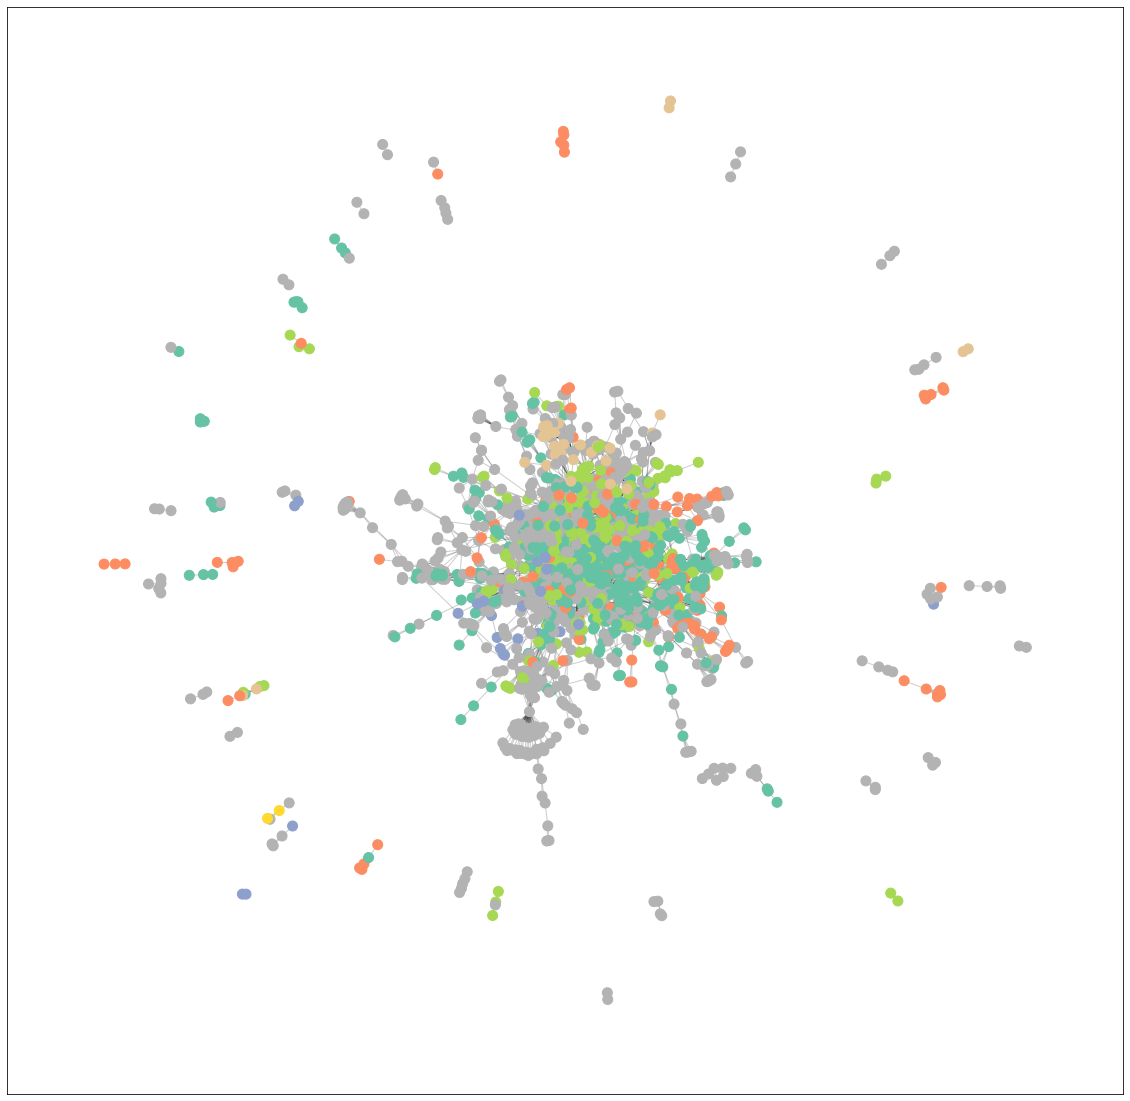

In [14]:
plt.figure(figsize=(20,20))
pos = nx.spring_layout(rcd_nwrev)
ec = nx.draw_networkx_edges(rcd_nwrev, pos, alpha=0.2)
nc = nx.draw_networkx_nodes(rcd_nwrev, pos, node_color=[colormap[node[1]['state']] for node in rcd_nwrev.nodes(data=True)], node_size=100)

([<matplotlib.axis.XTick at 0x146050280>,
 [Text(0, 0, 'STARVATION_AUTOPHAGY'),
  Text(1, 0, 'NECROPTOSIS'),
  Text(2, 0, 'FERROPTOSIS'),
  Text(3, 0, 'APOPTOSIS'),
  Text(4, 0, 'PARTHANATOS'),
  Text(5, 0, 'PYROPTOSIS'),
  Text(6, 0, 'RCD Other')])

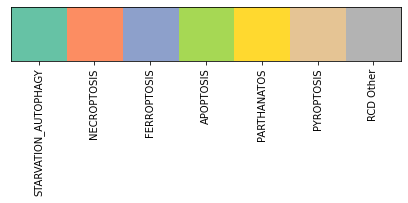

In [15]:
sns.palplot(colormap.values())
plt.xticks(np.arange(0, 7, step=1),labels=list(colormap.keys()), rotation=90)

In [16]:
revrcd_nwe_datadict

[('HTRA2@Mitochondrial intermembrane space', 'HTRA2', {}),
 ('HTRA2@Mitochondrial intermembrane space',
  'HAX1@Mitochondrial intermembrane space',
  {}),
 ('HTRA2@Mitochondrial intermembrane space',
  'cleaved~HAX1*@Mitochondrial intermembrane space',
  {}),
 ('DAB2IP', 'TNF', {}),
 ('DAB2IP', 'DAB2IP@TNFRSF1 Receptor Complex', {}),
 ('DAB2IP', 'ASK1*', {}),
 ('DAB2IP', 'ASK1*|unk|S967_pho', {}),
 ('DAB2IP', 'PP2A*', {}),
 ('DAB2IP', 'TRAF6', {}),
 ('DAB2IP', 'ASK1*|oligomer', {}),
 ('DAB2IP', 'NGFR-ICD*', {}),
 ('DAB2IP', 'DAB2IP|S604_pho@TNFRSF1 Receptor Complex', {}),
 ('DAB2IP', 'TRADD@TNFRSF1 Receptor Complex', {}),
 ('DAB2IP', 'TRAF2@TNFRSF1 Receptor Complex', {}),
 ('MAP2K4', 'MAP2K4|pho', {}),
 ('MAP2K4', 'ASK1*|pho|oligomer', {}),
 ('RIPK1|ubi@TNFRSF1 Receptor Complex', 'TNFAIP3', {}),
 ('RIPK1|ubi@TNFRSF1 Receptor Complex', 'ITCH|unk', {}),
 ('RIPK1|ubi@TNFRSF1 Receptor Complex', 'RNF11', {}),
 ('RIPK1|ubi@TNFRSF1 Receptor Complex', 'TAX1BP1', {}),
 ('RIPK1|ubi@TNFRSF1 Recep

In [17]:
tcganatgtex=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/tcganatgtex.txt",sep="\t",index_col=0)
tcganatgtex.dropna(how='all',inplace=True)
tcganatgtex

,Cancer,NAT,GTEX
TARGET-ALL,Acute Lymphoblastic Leukemia_White blood cell_...,NaN,NaN
TARGET-ALL,Acute Lymphoblastic Leukemia_White blood cell_...,NaN,NaN
TARGET-ALL,Acute Lymphoblastic Leukemia_White blood cell_...,NaN,NaN
TARGET-AML,Acute Myeloid Leukemia_White blood cell_Primar...,NaN,NaN
TCGA-LAML,Acute Myeloid Leukemia_White blood cell_Primar...,NaN,NaN
TARGET-AML,Acute Myeloid Leukemia_White blood cell_Recurr...,NaN,NaN
TARGET-AML,"Acute Myeloid Leukemia, Induction Failure Subp...",NaN,NaN
TARGET-AML,"Acute Myeloid Leukemia, Induction Failure Subp...",NaN,NaN
TCGA-ACC,Adrenocortical Cancer_Adrenal gland_Primary Tumor,NaN,Adrenal Gland_Adrenal Gland_Normal Tissue
TCGA-BLCA,Bladder Urothelial Carcinoma_Bladder_Primary T...,Bladder Urothelial Carcinoma_Bladder_Solid Tis...,Bladder_Bladder_Normal Tissue


In [18]:
tcganatgtex_dict=tcganatgtex[tcganatgtex['Cancer'].str.contains('_Primary Tumor')].to_dict()
combgenexfiles={}
for ctype in tcganatgtex_dict:
    for proj in tcganatgtex_dict[ctype]:
        if proj not in combgenexfiles:
            combgenexfiles[proj]=[]
        try:
            for file in tcganatgtex_dict[ctype][proj].split(","):
                combgenexfiles[proj].append(file)
        except:
            pass
combgenexfiles

{'TCGA-ACC': ['Adrenocortical Cancer_Adrenal gland_Primary Tumor',
  'Adrenal Gland_Adrenal Gland_Normal Tissue'],
 'TCGA-BLCA': ['Bladder Urothelial Carcinoma_Bladder_Primary Tumor',
  'Bladder Urothelial Carcinoma_Bladder_Solid Tissue Normal',
  'Bladder_Bladder_Normal Tissue'],
 'TCGA-LGG': ['Brain Lower Grade Glioma_Brain_Primary Tumor',
  'Brain - Amygdala_Brain_Normal Tissue',
  'Brain - Anterior Cingulate Cortex (Ba24)_Brain_Normal Tissue',
  'Brain - Caudate (Basal Ganglia)_Brain_Normal Tissue',
  'Brain - Cerebellar Hemisphere_Brain_Normal Tissue',
  'Brain - Cerebellum_Brain_Normal Tissue',
  'Brain - Cortex_Brain_Normal Tissue',
  'Brain - Frontal Cortex (Ba9)_Brain_Normal Tissue',
  'Brain - Hippocampus_Brain_Normal Tissue',
  'Brain - Hypothalamus_Brain_Normal Tissue',
  'Brain - Nucleus Accumbens (Basal Ganglia)_Brain_Normal Tissue',
  'Brain - Putamen (Basal Ganglia)_Brain_Normal Tissue',
  'Brain - Spinal Cord (Cervical C-1)_Brain_Normal Tissue',
  'Brain - Substantia N

In [19]:
rcdentrezlist=[]
newremlist=[]
for gene in revrcd_nw_datadict:
    if "ENTREZ" not in  revrcd_nw_datadict[gene]:
        newremlist+=[gene]
        continue
    if revrcd_nw_datadict[gene]['ENTREZ']!="":
        gl=revrcd_nw_datadict[gene]['ENTREZ'].split("@@")
    for g in gl:
        if g not in rcdentrezlist:
            rcdentrezlist.append(g)

In [20]:
len(rcdentrezlist)

927

In [21]:
for gene in revrcd_nw_datadict:
    print(revrcd_nw_datadict[gene])
    break

{'UNIPROT': 'O43464', 'CELLDESIGNER_ALIAS': 'sa5', 'CELLDESIGNER_SPECIES': 's5', 'CELLDESIGNER_NODE_TYPE': 'PROTEIN', 'HGNC': '14348', 'HUGO': 'HTRA2', 'canonicalName': 'HTRA2@Mitochondrial intermembrane space', 'ENTREZ': '27429', 'MODULE': 'APOPTOSIS@@CASPASES@@MOMP_REGULATION@@APOPTOSIS@@CASPASES@@MOMP_REGULATION', 'PMID': '23070005', 'state': 'APOPTOSIS'}


In [22]:
all_hgnc=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/all_hgnc_biomart.txt",sep='\t',index_col=8, dtype={'NCBI gene ID': str})
entoens=dict(zip(all_hgnc['NCBI gene ID'].values.tolist(),all_hgnc.index.tolist()))
ens2entrez=all_hgnc['NCBI gene ID'].to_dict()

In [23]:
rcdenslist=[]
for g in rcdentrezlist:
    try:
        rcdenslist.append(entoens[g])
    except:
        print(g)
        pass

In [24]:
len(rcdenslist)

927

In [25]:
revrcd_nw_datadict

{'HTRA2@Mitochondrial intermembrane space': {'UNIPROT': 'O43464',
  'CELLDESIGNER_ALIAS': 'sa5',
  'CELLDESIGNER_SPECIES': 's5',
  'CELLDESIGNER_NODE_TYPE': 'PROTEIN',
  'HGNC': '14348',
  'HUGO': 'HTRA2',
  'canonicalName': 'HTRA2@Mitochondrial intermembrane space',
  'ENTREZ': '27429',
  'MODULE': 'APOPTOSIS@@CASPASES@@MOMP_REGULATION@@APOPTOSIS@@CASPASES@@MOMP_REGULATION',
  'PMID': '23070005',
  'state': 'APOPTOSIS'},
 'DAB2IP': {'UNIPROT': 'Q15628@@Q12933@@Q5VWQ8',
  'CELLDESIGNER_ALIAS': 'csa345',
  'CELLDESIGNER_SPECIES': 's4171',
  'synonym': 'AIP1',
  'CELLDESIGNER_NODE_TYPE': 'COMPLEX',
  'HGNC': '12030@@12032@@17294',
  'HUGO': 'TRADD@@TRAF2@@DAB2IP',
  'canonicalName': 'DAB2IP|S604_pho:TRADD:TRAF2',
  'ENTREZ': '8717@@7186@@153090',
  'MODULE': 'APOPTOSIS@@DEATH_RECEPTOR_PATHWAYS@@NECROPTOSIS@@TNF_RESPONSE@@TRAIL_RESPONSE@@STARVATION_AUTOPHAGY@@DEATH_RECEPTOR_PATHWAYS@@FAS_RESPONSE@@TNF_RESPONSE@@TRAIL_RESPONSE@@ER_STRESS@@DEATH_RECEPTOR_PATHWAYS@@TNF_RESPONSE',
  'PMID': '

In [26]:
rcd_nwrev.remove_nodes_from(newremlist)

In [27]:
revrcd_nw_datadict=dict(rcd_nwrev.nodes.data())
nodeattributes=[]
for node in revrcd_nw_datadict:
    attlist=list(revrcd_nw_datadict[node].keys())
    for att in attlist:
        if att not in nodeattributes:
            nodeattributes.append(att)
revrcd_nwe_datadict=list(rcd_nwrev.edges.data())
revedgeattributes=[]
for edge in revrcd_nwe_datadict:
    attlist=list(edge[2].keys())
    for att in attlist:
        if att not in revedgeattributes:
            revedgeattributes.append(att)

In [28]:
def filter_corrdf(expdf,genelist):
    return expdf.loc[expdf.index.intersection(genelist)].transpose().corr()

In [29]:
corr_rcdgs={}
for ct in combgenexfiles:
    corr_rcdgs[ct]={}
    for file in combgenexfiles[ct]:
        try:
            expfile=pd.read_csv("deseqgeneexp/"+file+"_geneexp.tsv",index_col=0,sep="\t")
            corr_rcdgs[ct][file]=filter_corrdf(expfile,rcdenslist)
        except:
            pass
    if len(corr_rcdgs[ct])==0:
        del corr_rcdgs[ct]

In [30]:
for ct in corr_rcdgs:
    for file in corr_rcdgs[ct]:
        print(ct,file,np.percentile(corr_rcdgs[ct][file].melt().dropna().value,90))

TCGA-ACC Adrenocortical Cancer_Adrenal gland_Primary Tumor 0.49895729008301376
TCGA-ACC Adrenal Gland_Adrenal Gland_Normal Tissue 0.9343592993976312
TCGA-BLCA Bladder Urothelial Carcinoma_Bladder_Primary Tumor 0.4555552259296165
TCGA-BLCA Bladder Urothelial Carcinoma_Bladder_Solid Tissue Normal 0.6621411321410245
TCGA-LGG Brain Lower Grade Glioma_Brain_Primary Tumor 0.505365116173444
TCGA-LGG Brain - Amygdala_Brain_Normal Tissue 0.9579670203840586
TCGA-LGG Brain - Anterior Cingulate Cortex (Ba24)_Brain_Normal Tissue 0.5284216298612773
TCGA-LGG Brain - Caudate (Basal Ganglia)_Brain_Normal Tissue 0.48078489210066244
TCGA-LGG Brain - Cerebellar Hemisphere_Brain_Normal Tissue 0.4703154667268718
TCGA-LGG Brain - Cerebellum_Brain_Normal Tissue 0.9424453789218554
TCGA-LGG Brain - Cortex_Brain_Normal Tissue 0.5264366759446343
TCGA-LGG Brain - Frontal Cortex (Ba9)_Brain_Normal Tissue 0.9452912789272329
TCGA-LGG Brain - Hippocampus_Brain_Normal Tissue 0.5150219949202902
TCGA-LGG Brain - Hypothal

In [31]:
sthued={}
for ct in combgenexfiles:
    for file in combgenexfiles[ct]:
        if "_Primary Tumor" in file:
            sthued[file]="PT"
        elif "_Solid Tissue Normal" in file:
            sthued[file]="NAT"
        else:
            sthued[file]="GTEX"

In [32]:
tdf=pd.concat([pd.concat(corr_rcdgs[ct]).stack().reset_index() for ct in corr_rcdgs])
tdf.columns=["sampletype","g1","g2","corr"]

In [33]:
inv_combgenex={}
for ct in combgenexfiles:
    for file in combgenexfiles[ct]:
        inv_combgenex[file]=ct
tdf["proj"]=tdf["sampletype"].map(inv_combgenex)

In [34]:
tdf["sampltype2"]=tdf["sampletype"].map(sthued)

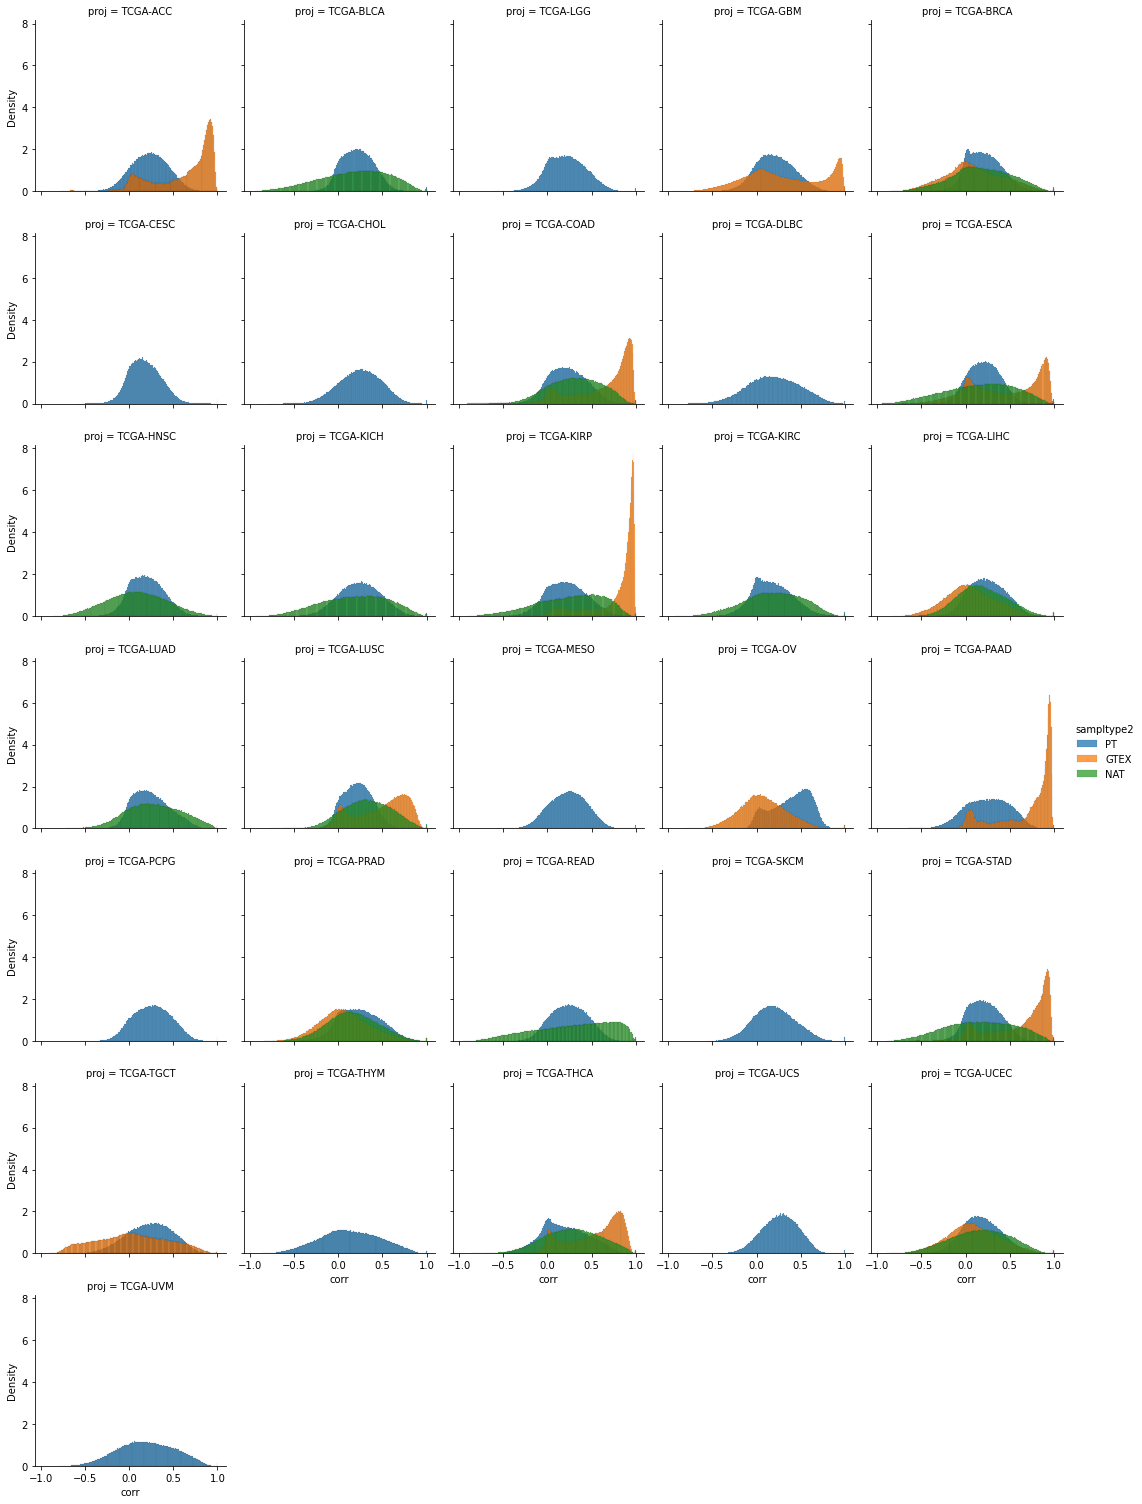

In [35]:
tdf=tdf.reset_index()
g = sns.FacetGrid(tdf, col='proj', hue="sampltype2", col_wrap=5)
g.map_dataframe(sns.histplot, x="corr",stat='density')
g.add_legend()

In [36]:
gtex_gex={}
for file in os.listdir("deseqgeneexp/"):
    if "_Normal Tissue" in file:
        if file.split("_")[0] not in gtex_gex.keys():
            gtex_gex[file.split("_")[0]]=[file]
        else:
            gtex_gex[file.split("_")[0]].append(file)

In [37]:
corr_rcd_gtex={}
for ct in gtex_gex:
    corr_rcd_gtex[ct]={}
    for file in gtex_gex[ct]:
            expfile=pd.read_csv("deseqgeneexp/"+file,index_col=0,sep="\t")
            corr_rcd_gtex[ct][file]=filter_corrdf(expfile,rcdenslist)

In [38]:
gdf=pd.concat([pd.concat(corr_rcd_gtex[ct]).stack().reset_index() for ct in corr_rcd_gtex])
gdf.columns=["sampletype","g1","g2","corr"]
inv_gtex_gex={}
for ct in gtex_gex:
    for file in gtex_gex[ct]:
        inv_gtex_gex[file]=ct
gdf["tissue"]=gdf["sampletype"].map(inv_gtex_gex)
gdf=gdf.reset_index()

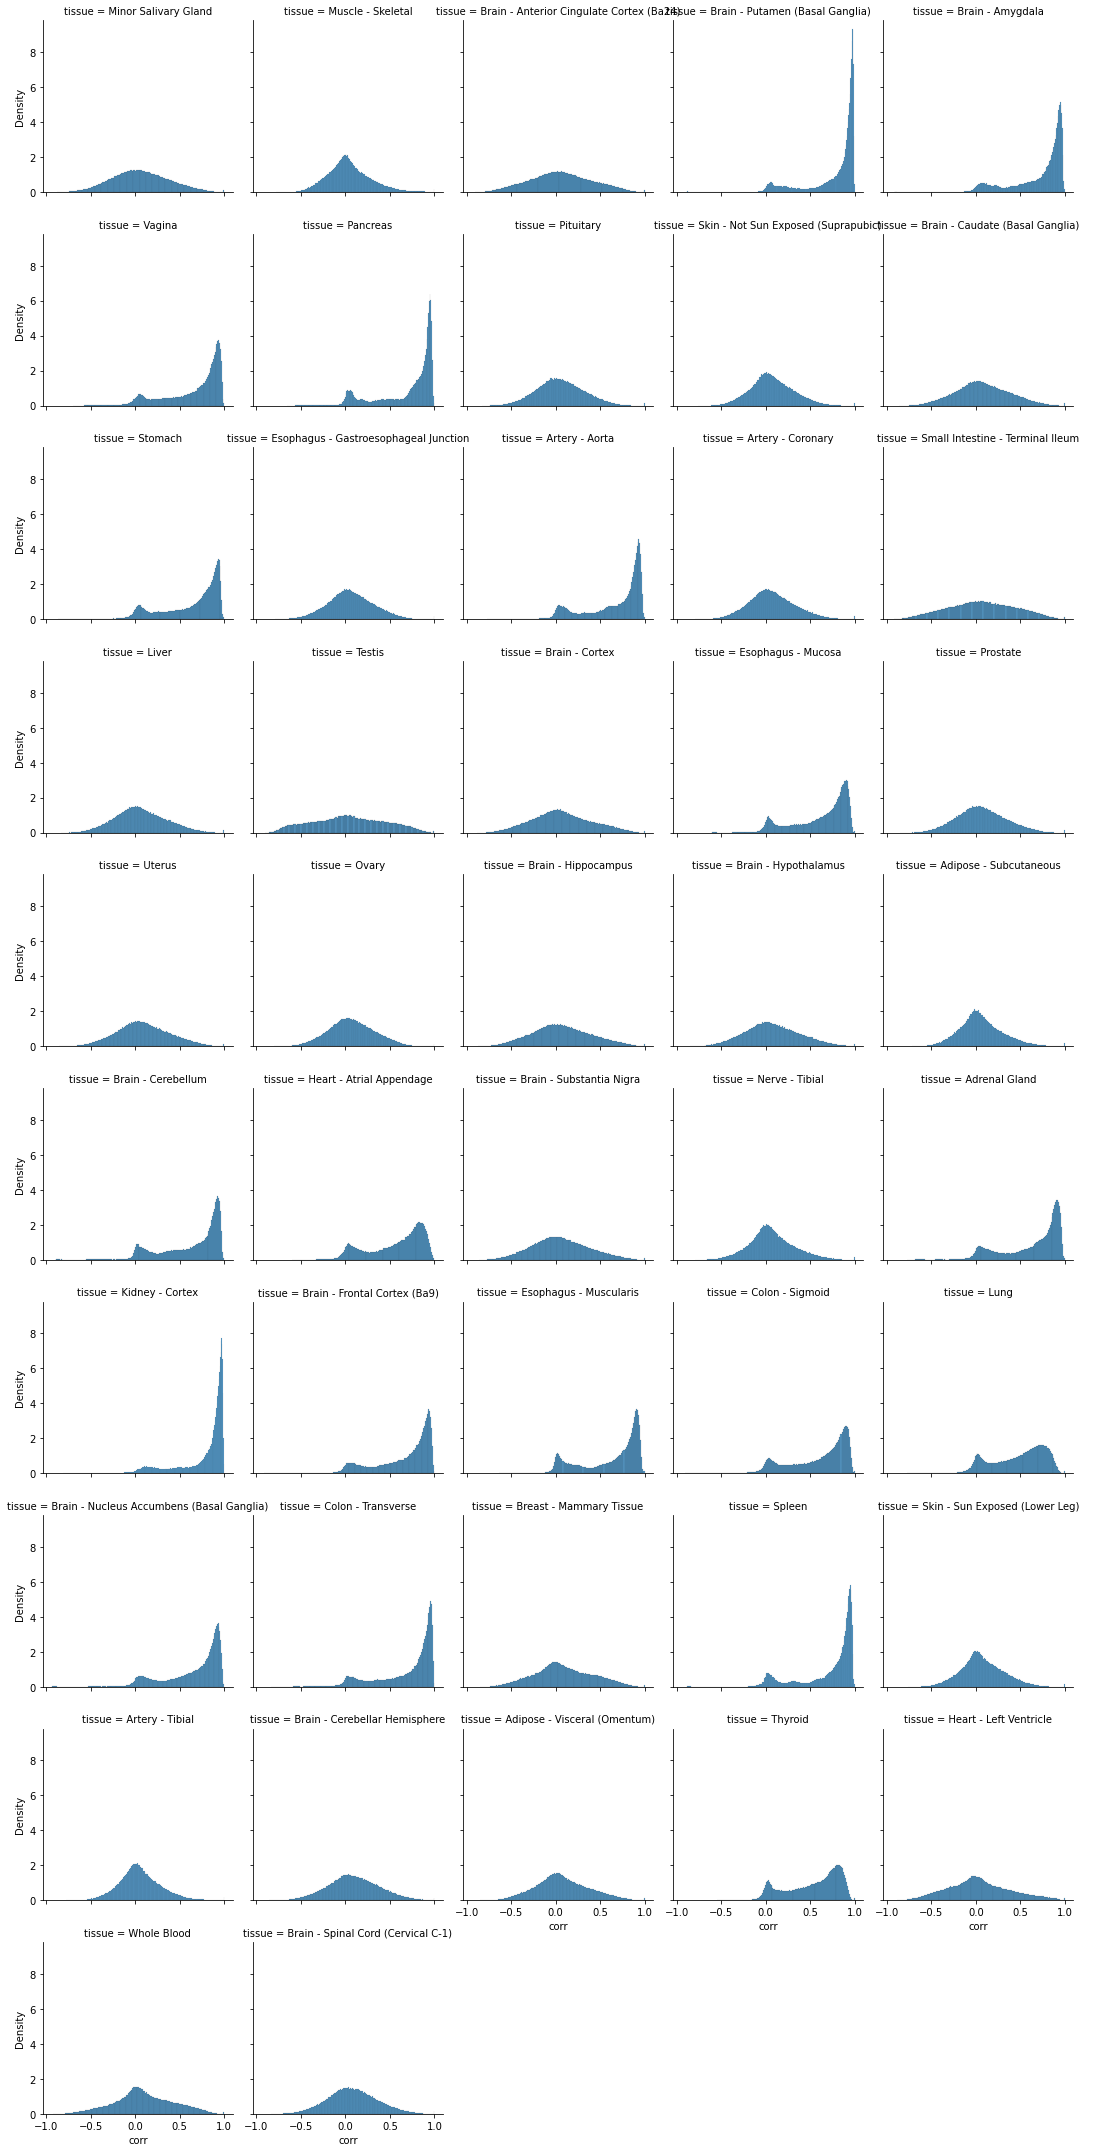

In [39]:
g = sns.FacetGrid(gdf, col='tissue', col_wrap=5)
g.map_dataframe(sns.histplot, x="corr",stat='density')
g.add_legend()

In [40]:
import pingouin as pg

In [41]:
gtexmetadata1=pd.read_csv("gtex_info/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt",sep="\t",index_col=0)
gtexmetadata1["subid"]=gtexmetadata1.index.str.split("-").str[0:2]
gtexmetadata1["subid"]=gtexmetadata1["subid"].str.join("-")
gtexmetadata1["subid"]

SAMPID
GTEX-1117F-0003-SM-58Q7G         GTEX-1117F
GTEX-1117F-0003-SM-5DWSB         GTEX-1117F
GTEX-1117F-0003-SM-6WBT7         GTEX-1117F
GTEX-1117F-0011-R10a-SM-AHZ7F    GTEX-1117F
GTEX-1117F-0011-R10b-SM-CYKQ8    GTEX-1117F
                                    ...    
K-562-SM-E9EZC                        K-562
K-562-SM-E9EZI                        K-562
K-562-SM-E9EZO                        K-562
K-562-SM-E9EZT                        K-562
K-562-SM-E9EZZ                        K-562
Name: subid, Length: 22951, dtype: object

In [37]:
gtexmetadata2=pd.read_csv("gtex_info/GTEx_Analysis_v8_Annotations_SubjectPhenotypesDS.txt",sep="\t",index_col=0)
gtexmetadata2

,SEX,AGE,DTHHRDY
SUBJID,,,
GTEX-1117F,2,60-69,4.0
GTEX-111CU,1,50-59,0.0
GTEX-111FC,1,60-69,1.0
GTEX-111VG,1,60-69,3.0
GTEX-111YS,1,60-69,0.0
...,...,...,...
GTEX-ZYY3,2,60-69,4.0
GTEX-ZZ64,1,20-29,0.0
GTEX-ZZPT,1,50-59,4.0


In [39]:
testgex=pd.read_csv("deseqgeneexp/"+gtex_gex["Breast - Mammary Tissue"][0],index_col=0,sep="\t")

In [41]:
gtexmetadata = gtexmetadata1.merge(gtexmetadata2, left_on='subid', right_on="SUBJID",right_index=True, how='inner', suffixes=('_1', '_2'))
gtexmetadata[["AGE","SMTSISCH"]]

,AGE,SMTSISCH
SAMPID,,
GTEX-1117F-0003-SM-58Q7G,60-69,1188.0
GTEX-1117F-0003-SM-5DWSB,60-69,1188.0
GTEX-1117F-0003-SM-6WBT7,60-69,1188.0
GTEX-1117F-0011-R10a-SM-AHZ7F,60-69,1193.0
GTEX-1117F-0011-R10b-SM-CYKQ8,60-69,1193.0
...,...,...
K-562-SM-E9EZC,50-59,NaN
K-562-SM-E9EZI,50-59,NaN
K-562-SM-E9EZO,50-59,NaN


In [42]:
testgex_wage=pd.concat([testgex.transpose(),gtexmetadata["SMTSISCH"]],join="inner",axis=1)
testgex_wage

,ENSG00000242268,ENSG00000259041,ENSG00000270112,ENSG00000167578,ENSG00000278814,ENSG00000078237,ENSG00000269416,ENSG00000263642,ENSG00000146083,ENSG00000158486,...,ENSG00000238244,ENSG00000216352,ENSG00000123685,ENSG00000267117,ENSG00000273233,ENSG00000105063,ENSG00000231119,ENSG00000280861,ENSG00000181518,SMTSISCH
GTEX-SE5C-2126-SM-4BRUJ,1.0640,0.0,1.0640,9.1530,0.0,7.8042,1.064,0.0,10.1913,1.6697,...,0.0000,0.0,6.4092,0.0000,0.0000,10.9558,3.7003,0.0,0.0000,221.0
GTEX-13CF2-2026-SM-5K7VI,3.0487,0.0,1.2158,9.3800,0.0,6.8993,1.866,0.0,10.5699,1.8660,...,0.0000,0.0,5.5635,1.5772,0.0000,10.5240,2.6532,0.0,0.0000,1406.0
GTEX-ZF3C-2326-SM-5S2MZ,0.8748,0.0,0.8748,9.1153,0.0,6.7511,0.000,0.0,10.5524,0.8748,...,0.8748,0.0,6.6227,2.3698,0.0000,10.1777,3.3464,0.0,0.0000,583.0
GTEX-Y9LG-1426-SM-5IFJZ,0.8746,0.0,1.4152,9.3886,0.0,7.7041,0.000,0.0,9.7695,0.8746,...,0.8746,0.0,6.3252,0.0000,0.8746,10.6465,3.4596,0.0,0.0000,116.0
GTEX-S7SE-0826-SM-4AT4D,2.8051,0.0,0.0000,9.6941,0.0,7.1074,0.000,0.0,10.2014,2.1448,...,0.0000,0.0,6.2041,1.8346,0.0000,10.1877,2.8051,0.0,0.0000,1059.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTEX-ZYT6-0126-SM-5E45J,4.6104,0.0,0.0000,9.4147,0.0,7.1087,0.000,0.0,10.1598,0.7739,...,0.0000,0.0,5.0728,1.2749,0.0000,10.5360,1.6460,0.0,0.0000,1398.0
GTEX-S33H-0326-SM-4AD6N,4.3799,0.0,2.4084,9.5438,0.0,7.4447,0.000,0.0,10.3535,3.7076,...,0.0000,0.0,6.2143,0.0000,1.4455,10.3591,2.6254,0.0,0.8967,209.0
GTEX-14753-2426-SM-5LU8U,2.4195,0.0,0.0000,9.3351,0.0,7.4149,0.000,0.0,10.2398,2.0917,...,0.0000,0.0,6.5459,0.0000,0.0000,10.0035,3.1064,0.0,0.0000,913.0
GTEX-11NSD-0926-SM-5N9DR,2.0814,0.0,0.8544,9.1707,0.0,7.2257,0.000,0.0,10.3157,0.8544,...,0.8544,0.0,5.6752,0.8544,1.7757,10.5898,3.0483,0.0,0.0000,95.0


In [43]:
testgex_wage.columns

Index(['ENSG00000242268', 'ENSG00000259041', 'ENSG00000270112',
       'ENSG00000167578', 'ENSG00000278814', 'ENSG00000078237',
       'ENSG00000269416', 'ENSG00000263642', 'ENSG00000146083',
       'ENSG00000158486',
       ...
       'ENSG00000238244', 'ENSG00000216352', 'ENSG00000123685',
       'ENSG00000267117', 'ENSG00000273233', 'ENSG00000105063',
       'ENSG00000231119', 'ENSG00000280861', 'ENSG00000181518', 'SMTSISCH'],
      dtype='object', length=60499)

In [44]:
parcorr=pg.pairwise_corr(testgex_wage,columns=testgex_wage.columns.intersection(rcdenslist).tolist(),covar="SMTSISCH")

In [48]:
parcorr

,X,Y,method,covar,alternative,n,r,CI95%,p-unc
0,ENSG00000078237,ENSG00000179262,pearson,['SMTSISCH'],two-sided,178,0.666083,"[0.58, 0.74]",4.677784e-24
1,ENSG00000078237,ENSG00000070081,pearson,['SMTSISCH'],two-sided,178,-0.030803,"[-0.18, 0.12]",6.840118e-01
2,ENSG00000078237,ENSG00000149089,pearson,['SMTSISCH'],two-sided,178,0.527594,"[0.41, 0.63]",4.514616e-14
3,ENSG00000078237,ENSG00000138495,pearson,['SMTSISCH'],two-sided,178,0.663729,"[0.57, 0.74]",7.670334e-24
4,ENSG00000078237,ENSG00000164116,pearson,['SMTSISCH'],two-sided,178,-0.403862,"[-0.52, -0.27]",2.485977e-08
...,...,...,...,...,...,...,...,...,...
353215,ENSG00000177076,ENSG00000164919,pearson,['SMTSISCH'],two-sided,178,0.117435,"[-0.03, 0.26]",1.195445e-01
353216,ENSG00000177076,ENSG00000171953,pearson,['SMTSISCH'],two-sided,178,-0.275689,"[-0.41, -0.13]",2.039692e-04
353217,ENSG00000110330,ENSG00000164919,pearson,['SMTSISCH'],two-sided,178,0.102121,"[-0.05, 0.25]",1.762003e-01
353218,ENSG00000110330,ENSG00000171953,pearson,['SMTSISCH'],two-sided,178,-0.061373,"[-0.21, 0.09]",4.170837e-01


<AxesSubplot:xlabel='r', ylabel='Proportion'>

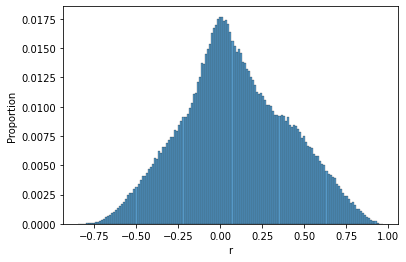

In [49]:
sns.histplot(data=parcorr,x="r",stat="proportion")

In [ ]:
par_corr_rcd_gtex={}
for ct in gtex_gex:
    par_corr_rcd_gtex[ct]={}
    for file in gtex_gex[ct]:
            expfile=pd.read_csv("deseqgeneexp/"+file,index_col=0,sep="\t")
            expfile_wage=pd.concat([expfile.transpose(),gtexmetadata["SMTSISCH"]],join="inner",axis=1)
            par_corr_rcd_gtex[ct][file]=pg.pairwise_corr(expfile_wage,columns=expfile_wage.columns.intersection(rcdenslist).tolist(),covar="SMTSISCH")

In [47]:
testgex.transpose(),gtexmetadata["SMTSISCH"]

,GTEX-SE5C-2126-SM-4BRUJ,GTEX-13CF2-2026-SM-5K7VI,GTEX-ZF3C-2326-SM-5S2MZ,GTEX-Y9LG-1426-SM-5IFJZ,GTEX-S7SE-0826-SM-4AT4D,GTEX-R55F-1726-SM-2TF4R,GTEX-131YS-0626-SM-5EGKL,GTEX-14E6E-1326-SM-5S2NR,GTEX-ZUA1-1526-SM-59HLS,GTEX-ZXES-0826-SM-5E43C,...,GTEX-13PL6-2926-SM-5L3I2,GTEX-WOFL-0826-SM-3MJG1,GTEX-YFC4-1426-SM-5IFJG,GTEX-13W3W-1226-SM-5LU4H,GTEX-13S86-1226-SM-5S2OA,GTEX-ZYT6-0126-SM-5E45J,GTEX-S33H-0326-SM-4AD6N,GTEX-14753-2426-SM-5LU8U,GTEX-11NSD-0926-SM-5N9DR,GTEX-ZT9W-2026-SM-51MRA
ENSG00000242268,1.0640,3.0487,0.8748,0.8746,2.8051,0.7977,1.9851,3.1045,3.4486,0.0000,...,0.0000,0.0000,0.0000,0.9145,1.5554,4.6104,4.3799,2.4195,2.0814,1.8407
ENSG00000259041,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
ENSG00000270112,1.0640,1.2158,0.8748,1.4152,0.0000,1.3084,0.0000,0.9636,0.0000,0.6442,...,0.7467,0.0000,1.4274,0.9145,0.0000,0.0000,2.4084,0.0000,0.8544,2.4068
ENSG00000167578,9.1530,9.3800,9.1153,9.3886,9.6941,8.6874,8.9646,9.2772,9.4587,8.7478,...,9.2475,9.1817,9.4465,9.1481,9.2975,9.4147,9.5438,9.3351,9.1707,9.5285
ENSG00000278814,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000273233,0.0000,0.0000,0.0000,0.8746,0.0000,0.0000,0.7989,0.9636,0.8180,0.6442,...,1.6012,0.5758,0.0000,1.8698,0.9779,0.0000,1.4455,0.0000,1.7757,0.0000
ENSG00000105063,10.9558,10.5240,10.1777,10.6465,10.1877,10.1335,10.5027,10.7827,10.5092,10.4624,...,10.2797,10.3467,10.4302,10.6692,11.3190,10.5360,10.3591,10.0035,10.5898,10.9320
ENSG00000231119,3.7003,2.6532,3.3464,3.4596,2.8051,3.6796,2.4432,3.6324,2.8285,2.4602,...,3.4815,3.8321,2.6014,1.4698,1.5554,1.6460,2.6254,3.1064,3.0483,2.6238
ENSG00000280861,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [293]:
nodegenemap={}
for gene in revrcd_nw_datadict:
    nodegenemap[gene]=[]
    gl=revrcd_nw_datadict[gene]['ENTREZ'].split("@@")
    for g in gl:
        nodegenemap[gene].append(entoens[g])

In [295]:
def prune_edges(nw,corr,thresh):
    remedges=[]
    for edges in nw.edges():
        cv=corr.loc[corr.index.intersection(nodegenemap[edges[0]]),corr.columns.intersection(nodegenemap[edges[1]])].melt().max().value    
        if np.isnan(cv):
            remedges.append(edges)
        elif cv<thresh:
            remedges.append(edges)
    nw.remove_edges_from(remedges)
    nw.remove_nodes_from(list(nx.isolates(nw)))
    return nw

In [137]:
list(rcd_nwrev.edges())

[('HTRA2@Mitochondrial intermembrane space', 'HTRA2'),
 ('HTRA2@Mitochondrial intermembrane space',
  'HAX1@Mitochondrial intermembrane space'),
 ('HTRA2@Mitochondrial intermembrane space',
  'cleaved~HAX1*@Mitochondrial intermembrane space'),
 ('DAB2IP', 'TNF'),
 ('DAB2IP', 'DAB2IP@TNFRSF1 Receptor Complex'),
 ('DAB2IP', 'ASK1*'),
 ('DAB2IP', 'ASK1*|unk|S967_pho'),
 ('DAB2IP', 'PP2A*'),
 ('DAB2IP', 'TRAF6'),
 ('DAB2IP', 'ASK1*|oligomer'),
 ('DAB2IP', 'NGFR-ICD*'),
 ('DAB2IP', 'DAB2IP|S604_pho@TNFRSF1 Receptor Complex'),
 ('DAB2IP', 'TRADD@TNFRSF1 Receptor Complex'),
 ('DAB2IP', 'TRAF2@TNFRSF1 Receptor Complex'),
 ('MAP2K4', 'MAP2K4|pho'),
 ('MAP2K4', 'ASK1*|pho|oligomer'),
 ('RIPK1|ubi@TNFRSF1 Receptor Complex', 'TNFAIP3'),
 ('RIPK1|ubi@TNFRSF1 Receptor Complex', 'ITCH|unk'),
 ('RIPK1|ubi@TNFRSF1 Receptor Complex', 'RNF11'),
 ('RIPK1|ubi@TNFRSF1 Receptor Complex', 'TAX1BP1'),
 ('RIPK1|ubi@TNFRSF1 Receptor Complex', 'RIPK1@TNFRSF1 Receptor Complex'),
 ('Caspase9*@Mitochondrial intermem

In [296]:
pruned_networks={}
for ct in corr_rcdgs:
    pruned_networks[ct]={}
    for file in corr_rcdgs[ct]:
        rcd_nwrev_copy=rcd_nwrev.copy()
        pruned_networks[ct][file]=prune_edges(rcd_nwrev_copy,corr_rcdgs[ct][file],np.percentile(corr_rcdgs[ct][file].melt().dropna().value,90))

In [211]:
np.isnan(cv)

False

In [231]:
corr_rcdgs.keys()

dict_keys(['TCGA-BRCA', 'TCGA-COAD', 'TCGA-ESCA', 'TCGA-KICH', 'TCGA-KIRC', 'TCGA-KIRP', 'TCGA-LIHC', 'TCGA-LUAD', 'TCGA-LUSC', 'TCGA-PRAD', 'TCGA-STAD', 'TCGA-THCA', 'TCGA-UCEC'])

In [297]:
for ct in pruned_networks:
    for file in pruned_networks[ct]:
        print(file,nx.info(pruned_networks[ct][file]))

Breast Invasive Carcinoma_Breast_Primary Tumor Graph named 'Regulated Cell Death' with 1724 nodes and 1983 edges
Breast Invasive Carcinoma_Breast_Solid Tissue Normal Graph named 'Regulated Cell Death' with 1719 nodes and 2005 edges
Breast - Mammary Tissue_Breast_Normal Tissue Graph named 'Regulated Cell Death' with 1698 nodes and 1833 edges
Colon Adenocarcinoma_Colon_Primary Tumor Graph named 'Regulated Cell Death' with 1738 nodes and 2054 edges
Colon Adenocarcinoma_Colon_Solid Tissue Normal Graph named 'Regulated Cell Death' with 1718 nodes and 2074 edges
Colon - Sigmoid_Colon_Normal Tissue Graph named 'Regulated Cell Death' with 1702 nodes and 1813 edges
Colon - Transverse_Colon_Normal Tissue Graph named 'Regulated Cell Death' with 1703 nodes and 1843 edges
Esophageal Carcinoma_Esophagus_Primary Tumor Graph named 'Regulated Cell Death' with 1729 nodes and 2143 edges
Esophageal Carcinoma_Esophagus_Solid Tissue Normal Graph named 'Regulated Cell Death' with 1733 nodes and 2072 edges
Es

In [385]:
proj=["Processed"]
stype=["NA"]
nodesize=[rcd_nwrev.number_of_nodes()]
edgesize=[rcd_nwrev.number_of_edges()]
for ct in pruned_networks:
    for file in pruned_networks[ct]:
        nodesize.append(pruned_networks[ct][file].number_of_nodes())
        edgesize.append(pruned_networks[ct][file].number_of_edges())
        proj.append(ct)
        stype.append(sthued[file])
scat_network=pd.DataFrame({"Project":pd.Series(proj),"sampletype":pd.Series(stype),"Nodes":pd.Series(nodesize),"Edges":pd.Series(edgesize)})

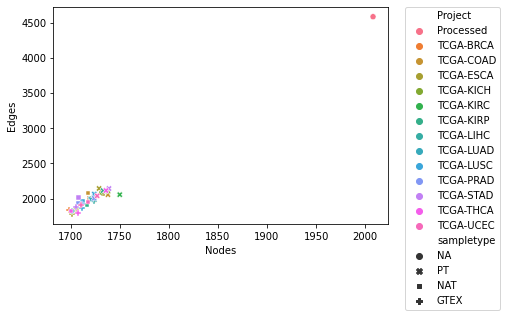

In [386]:
sns.scatterplot(data=scat_network,x="Nodes",y="Edges",hue="Project",style="sampletype")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

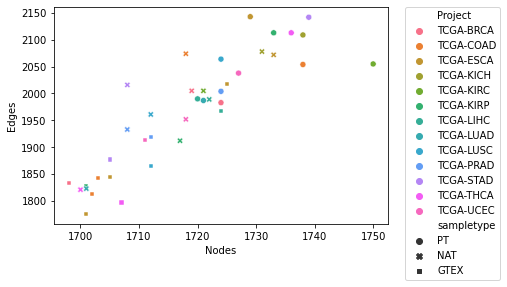

In [387]:
sns.scatterplot(data=scat_network[scat_network["Project"]!="Processed"],x="Nodes",y="Edges",hue="Project",style="sampletype")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [419]:
degree_dist={}
for ct in pruned_networks:
    for file in pruned_networks[ct]:
        degree_dist[file]=pd.Series({k: v for k, v in sorted(dict(pruned_networks[ct][file].degree).items(), key=lambda item: item[1], reverse=True)})
degreedf=pd.concat(degree_dist)

In [420]:
degreedf=degreedf.reset_index()
degreedf.columns=["sampletype","node","degree"]
degreedf["proj"]=degreedf["sampletype"].map(inv_combgenex)
degreedf["sampletype2"]=degreedf["sampletype"].map(sthued)

In [421]:
degreedf

,sampletype,node,degree,proj,sampletype2
0,Breast Invasive Carcinoma_Breast_Primary Tumor,BAX,24,TCGA-BRCA,PT
1,Breast Invasive Carcinoma_Breast_Primary Tumor,MLST8,24,TCGA-BRCA,PT
2,Breast Invasive Carcinoma_Breast_Primary Tumor,14-3-3*,17,TCGA-BRCA,PT
3,Breast Invasive Carcinoma_Breast_Primary Tumor,FADD,17,TCGA-BRCA,PT
4,Breast Invasive Carcinoma_Breast_Primary Tumor,NFKB1@Nucleus,16,TCGA-BRCA,PT
...,...,...,...,...,...
67012,Uterus_Uterus_Normal Tissue,HMGB1,1,TCGA-UCEC,GTEX
67013,Uterus_Uterus_Normal Tissue,IL1A@Extracellular space,1,TCGA-UCEC,GTEX
67014,Uterus_Uterus_Normal Tissue,HMGB1@Extracellular space,1,TCGA-UCEC,GTEX
67015,Uterus_Uterus_Normal Tissue,gMT-DNA*@Mitochondrial inner membrane,1,TCGA-UCEC,GTEX


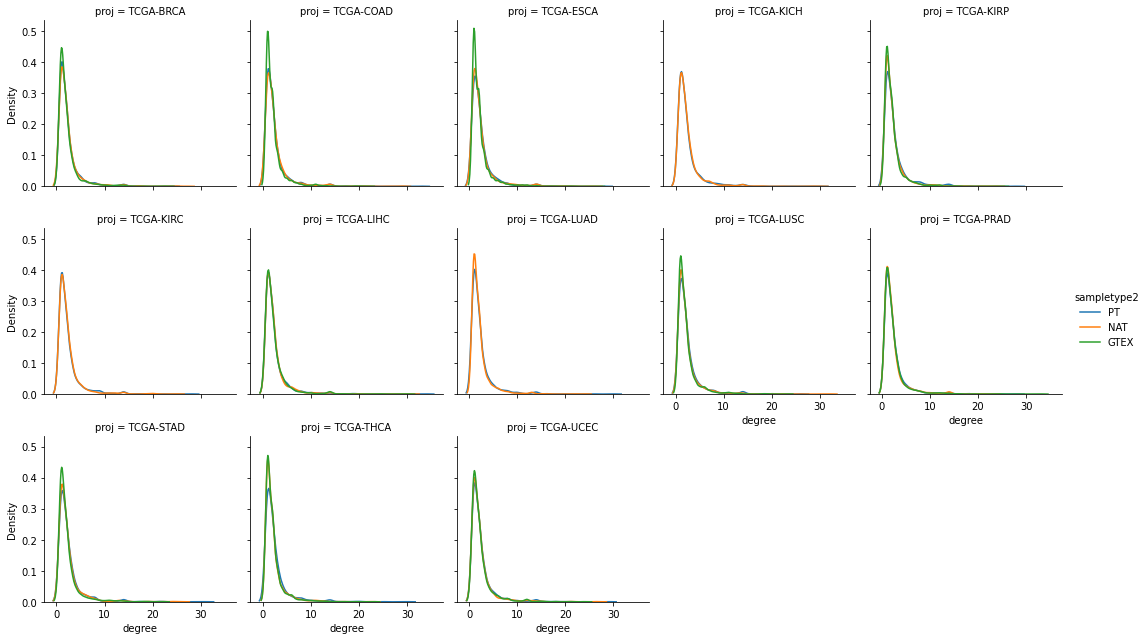

In [422]:
g = sns.FacetGrid(degreedf, col='proj', hue="sampletype2", col_wrap=5)
g.map_dataframe(sns.kdeplot, x="degree")
g.add_legend()

In [488]:
uniquenodes={}
for ct in combgenexfiles:
    uniquenodes[ct]={}
    for file in combgenexfiles[ct]:
        uniquenodes[ct][file]=set(degreedf[(degreedf["proj"]==ct) & (degreedf["sampletype"]==file)]['node'].values.tolist()) - set(degreedf[(degreedf["proj"]==ct) & (degreedf["sampletype"]!=file)]['node'].values.tolist())

In [501]:
nuniquenodes={}
for ct in uniquenodes:
    for file in uniquenodes[ct]:
        nuniquenodes[file]=len(uniquenodes[ct][file])

In [530]:
tdf=pd.DataFrame.from_dict(nuniquenodes,orient="index")

In [531]:
tdf=tdf.reset_index()
tdf["proj"]=tdf["index"].map(inv_combgenex)
tdf["sampletype2"]=tdf["index"].map(sthued)

In [534]:
tdf.columns=["index","uniquenodes","proj","sampletype2"]

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 [Text(0, 0, 'TCGA-BRCA'),
  Text(1, 0, 'TCGA-COAD'),
  Text(2, 0, 'TCGA-ESCA'),
  Text(3, 0, 'TCGA-KICH'),
  Text(4, 0, 'TCGA-KIRP'),
  Text(5, 0, 'TCGA-KIRC'),
  Text(6, 0, 'TCGA-LIHC'),
  Text(7, 0, 'TCGA-LUAD'),
  Text(8, 0, 'TCGA-LUSC'),
  Text(9, 0, 'TCGA-PRAD'),
  Text(10, 0, 'TCGA-STAD'),
  Text(11, 0, 'TCGA-THCA'),
  Text(12, 0, 'TCGA-UCEC')])

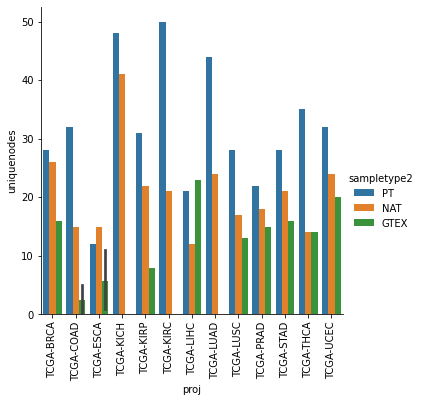

In [540]:
g = sns.catplot(x="proj", y="uniquenodes",
                hue="sampletype2", data=tdf,kind='bar')
plt.xticks(rotation=90)

In [549]:
len(set(pruned_networks["TCGA-BRCA"]["Breast Invasive Carcinoma_Breast_Solid Tissue Normal"].edges)-(set(pruned_networks["TCGA-BRCA"]["Breast - Mammary Tissue_Breast_Normal Tissue"].edges).union(set(pruned_networks["TCGA-BRCA"]["Breast Invasive Carcinoma_Breast_Primary Tumor"].edges))))

228

In [566]:
nuniqueedges={}
for ct in combgenexfiles:
    for file in combgenexfiles[ct]:
        nuniqueedges[file]=len(set(pruned_networks[ct][file].edges) -set([edge for f2 in combgenexfiles[ct] if f2!=file for edge in list(pruned_networks[ct][f2].edges)]))

In [569]:
tdf=pd.DataFrame.from_dict(nuniqueedges,orient="index")
tdf=tdf.reset_index()
tdf["proj"]=tdf["index"].map(inv_combgenex)
tdf["sampletype2"]=tdf["index"].map(sthued)
tdf.columns=["index","uniqueedges","proj","sampletype2"]

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 [Text(0, 0, 'TCGA-BRCA'),
  Text(1, 0, 'TCGA-COAD'),
  Text(2, 0, 'TCGA-ESCA'),
  Text(3, 0, 'TCGA-KICH'),
  Text(4, 0, 'TCGA-KIRP'),
  Text(5, 0, 'TCGA-KIRC'),
  Text(6, 0, 'TCGA-LIHC'),
  Text(7, 0, 'TCGA-LUAD'),
  Text(8, 0, 'TCGA-LUSC'),
  Text(9, 0, 'TCGA-PRAD'),
  Text(10, 0, 'TCGA-STAD'),
  Text(11, 0, 'TCGA-THCA'),
  Text(12, 0, 'TCGA-UCEC')])

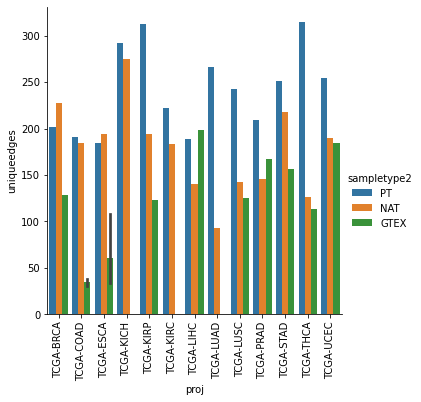

In [570]:
g = sns.catplot(x="proj", y="uniqueedges",
                hue="sampletype2", data=tdf,kind='bar')
plt.xticks(rotation=90)

In [577]:
uniquenodes={}
for ct in combgenexfiles:
    uniquenodes[ct]={}
    for file in combgenexfiles[ct]:
        uniquenodes[ct][file]=set(degreedf[(degreedf["proj"]==ct) & (degreedf["sampletype"]==file)]['node'].values.tolist()[:100]) - set(degreedf[(degreedf["proj"]==ct) & (degreedf["sampletype"]!=file)]['node'].values.tolist())

In [578]:
nuniquenodes={}
for ct in uniquenodes:
    for file in uniquenodes[ct]:
        nuniquenodes[file]=len(uniquenodes[ct][file])

In [579]:
tdf=pd.DataFrame.from_dict(nuniquenodes,orient="index")
tdf=tdf.reset_index()
tdf["proj"]=tdf["index"].map(inv_combgenex)
tdf["sampletype2"]=tdf["index"].map(sthued)
tdf.columns=["index","uniquenodes","proj","sampletype2"]

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 [Text(0, 0, 'TCGA-BRCA'),
  Text(1, 0, 'TCGA-COAD'),
  Text(2, 0, 'TCGA-ESCA'),
  Text(3, 0, 'TCGA-KICH'),
  Text(4, 0, 'TCGA-KIRP'),
  Text(5, 0, 'TCGA-KIRC'),
  Text(6, 0, 'TCGA-LIHC'),
  Text(7, 0, 'TCGA-LUAD'),
  Text(8, 0, 'TCGA-LUSC'),
  Text(9, 0, 'TCGA-PRAD'),
  Text(10, 0, 'TCGA-STAD'),
  Text(11, 0, 'TCGA-THCA'),
  Text(12, 0, 'TCGA-UCEC')])

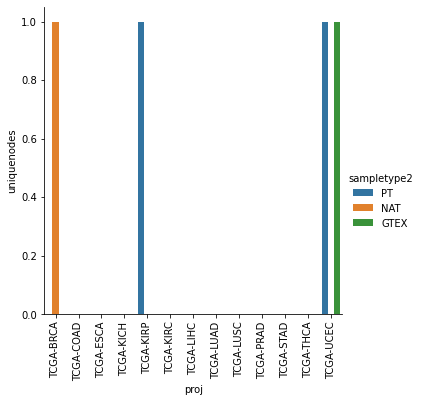

In [580]:
g = sns.catplot(x="proj", y="uniquenodes",
                hue="sampletype2", data=tdf,kind='bar')
plt.xticks(rotation=90)

In [581]:
uniquenodes

{'TCGA-BRCA': {'Breast Invasive Carcinoma_Breast_Primary Tumor': set(),
  'Breast Invasive Carcinoma_Breast_Solid Tissue Normal': {'active~Caspases*'},
  'Breast - Mammary Tissue_Breast_Normal Tissue': set()},
 'TCGA-COAD': {'Colon Adenocarcinoma_Colon_Primary Tumor': set(),
  'Colon Adenocarcinoma_Colon_Solid Tissue Normal': set(),
  'Colon - Sigmoid_Colon_Normal Tissue': set(),
  'Colon - Transverse_Colon_Normal Tissue': set()},
 'TCGA-ESCA': {'Esophageal Carcinoma_Esophagus_Primary Tumor': set(),
  'Esophageal Carcinoma_Esophagus_Solid Tissue Normal': set(),
  'Esophagus - Gastroesophageal Junction_Esophagus_Normal Tissue': set(),
  'Esophagus - Mucosa_Esophagus_Normal Tissue': set(),
  'Esophagus - Muscularis_Esophagus_Normal Tissue': set()},
 'TCGA-KICH': {'Kidney Chromophobe_Kidney_Primary Tumor': set(),
  'Kidney Chromophobe_Kidney_Solid Tissue Normal': set(),
  'Kidney - Cortex_Kidney_Normal Tissue': set()},
 'TCGA-KIRC': {'Kidney Clear Cell Carcinoma_Kidney_Primary Tumor': set